# Notebook 04 — Neurotoxicity & Blood-Brain Barrier Prediction
**Author: Himanshu Goel** | [Website](https://hgoelgithub.github.io)

---

## Overview

Neurotoxicity assessment is multi-layered. Before a chemical can harm the CNS it must first
**cross the blood-brain barrier (BBB)**. Once inside, it can act through several mechanisms:

| Mechanism | Example chemicals | Key endpoint |
|-----------|------------------|-------------|
| AChE inhibition | Organophosphates, carbamates | Cholinergic crisis |
| BBB permeability | CNS drugs, solvents | CNS penetration |
| Oxidative stress | Reactive oxygen species | Neuronal apoptosis |
| Ion channel modulation | Pyrethroids, DDT | Seizures |

This notebook covers the **first two layers** using cheminformatics + ML.

### Learning Objectives
1. Compute Lipinski/BBB physicochemical descriptors with RDKit  
2. Apply the **BBB-Score** rule-based filter (Gupta et al. 2019)  
3. Apply the **CNS MPO score** (Pfizer multi-parameter optimisation)  
4. Train and cross-validate **Random Forest** and **XGBoost** classifiers for BBB penetration  
5. Predict **AChE inhibition** probability from ECFP fingerprints  
6. Visualise chemical space and model performance  

### Key References
- Gupta et al. (2019) *J. Med. Chem.* — BBB-Score validated on 1 058 CNS drugs  
- Meng et al. (2021) *J. Chem. Inf. Model.* — B3DB dataset (7 000+ compounds)  
- Wager et al. (2010) *ACS Chem. Neurosci.* — CNS MPO desirability framework  

---
## Step 1 — Environment Setup

Install required packages. In a managed environment (Conda, Docker) these are typically
pre-installed. The `-q` flag suppresses verbose output.

In [1]:
!pip install rdkit scikit-learn pandas numpy matplotlib xgboost -q

---
## Step 2 — Imports

We use:
- **RDKit** for SMILES parsing, fingerprint generation, and physicochemical descriptors
- **scikit-learn** for cross-validated classification
- **XGBoost** as a gradient-boosted alternative to Random Forest
- **Matplotlib / Pandas** for visualisation and tabular output

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier

print("All imports successful.")

All imports successful.


---
## Step 3 — BBB Dataset

A curated subset from **B3DB** (Meng et al. 2021).  
- **Label 1** = BBB-penetrant (CNS drugs, psychoactives, lipophilic small molecules)  
- **Label 0** = BBB-impermeable (large polar molecules, charged species, hydrophilics)

Each entry is a `(SMILES, label, name)` tuple. We validate SMILES before use.

In [3]:
# (SMILES, BBB_label, name)
# Label: 1 = BBB-penetrant, 0 = BBB-impermeable
BBB_RAW = [
    # --- BBB-penetrant (CNS active) ---
    ("Cn1cnc2c1c(=O)n(C)c(=O)n2C",        1, "Caffeine"),
    ("CC(N)Cc1ccccc1",                      1, "Amphetamine"),
    ("CNCCC(c1ccccc1)Oc1ccc(C(F)(F)F)cc1", 1, "Fluoxetine"),
    ("CC(C)NCC(O)COc1cccc2ccccc12",         1, "Propranolol"),
    ("OC1=CC=C2CC3N(CCC34CCc5c4cc(O)c(OC)c5)C2=C1", 1, "Morphine"),
    ("c1ccc2c(c1)CCc1ccccc1-2",             1, "Fluorene"),
    ("FC(F)(F)c1ccc(N)cc1",                 1, "4-CF3-Aniline"),
    ("CC1CC2CC1C(N)(c1ccccc1)C2",           1, "PCP-Analog"),
    ("CC(C)(C)Nc1ccc(O)cc1",                1, "tBu-4-Aminophenol"),
    ("c1ccc2[nH]ccc2c1",                    1, "Indole"),
    # --- BBB-impermeable ---
    ("CC1(C)SC2C(NC(=O)Cc3ccccc3)C(=O)N2C1C(=O)O", 0, "Penicillin G"),
    ("CN(C)C(=N)NC(=N)N",                   0, "Metformin"),
    ("OC(=O)c1ccc(N)cc1",                   0, "4-Aminobenzoic acid"),
    ("OCC(O)CO",                             0, "Glycerol"),
    ("OC(=O)CC(O)(CC(=O)O)C(=O)O",          0, "Citric acid"),
    ("O=C(O)c1ccccc1C(=O)O",                0, "Phthalic acid"),
    ("OC(=O)CCCC(=O)O",                     0, "Glutaric acid"),
    ("NC(CS)C(=O)O",                         0, "Cysteine"),
    ("OC(=O)c1ccc(O)cc1",                   0, "4-Hydroxybenzoic acid"),
    ("CC(C)NCC(O)COc1ccc(CC(N)=O)cc1",     0, "Atenolol"),
]

# Validate SMILES — drop entries RDKit cannot parse
bbb_data = [
    (smi, lbl, name)
    for smi, lbl, name in BBB_RAW
    if Chem.MolFromSmiles(smi) is not None
]

n_pos = sum(l for _, l, _ in bbb_data)
n_neg = len(bbb_data) - n_pos
print(f"Dataset: {len(bbb_data)} compounds  |  BBB+: {n_pos}  |  BBB-: {n_neg}")

Dataset: 20 compounds  |  BBB+: 10  |  BBB-: 10


---
## Step 4 — Molecular Feature Engineering

We combine two complementary feature types:

| Feature type | Dimensionality | What it captures |
|---|---|---|
| **ECFP4 fingerprint** | 1 024 bits | Circular atom environment (topology) |
| **Physicochemical descriptors** | 10 values | MW, LogP, TPSA, HBD, HBA, Fsp³, ArRings, MR, nRings, BBB-rule flag |

The BBB-rule flag encodes the simplified Gupta criterion as a single binary feature,
giving the ML model a pre-computed domain-knowledge hint.

In [4]:
def compute_features(smiles: str) -> np.ndarray | None:
    """Return concatenated ECFP4 + physicochemical feature vector, or None on parse failure."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # ECFP4 (radius=2, 1024 bits) — captures local chemical environment
    ecfp = np.array(
        AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024),
        dtype=np.float32
    )

    mw   = Descriptors.ExactMolWt(mol)
    logp = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    hba  = rdMolDescriptors.CalcNumHBA(mol)
    fsp3 = Descriptors.FractionCSP3(mol)
    ar   = rdMolDescriptors.CalcNumAromaticRings(mol)
    mr   = Descriptors.MolMR(mol)
    nring = rdMolDescriptors.CalcNumRings(mol)

    # Simplified BBB rule flag (Gupta 2019): all four criteria must pass
    bbb_rule = float(tpsa < 90 and hbd <= 3 and mw < 450 and 0 < logp < 5)

    physchem = np.array(
        [mw, logp, tpsa, hbd, hba, fsp3, ar, mr, nring, bbb_rule],
        dtype=np.float32
    )

    return np.concatenate([ecfp, physchem])


# Build feature matrix and label vector
X = np.array([compute_features(smi) for smi, _, _ in bbb_data])
y = np.array([lbl for _, lbl, _ in bbb_data])
names = [name for _, _, name in bbb_data]

# Scale features (important for models sensitive to feature magnitude)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X.shape}  (samples × features)")
print(f"  - ECFP4 bits      : 1024")
print(f"  - Physicochemical : 10")

[14:20:59] DEPRECATION WARNING: please use MorganGenerator
[14:20:59] DEPRECATION WARNING: please use MorganGenerator
[14:20:59] DEPRECATION WARNING: please use MorganGenerator
[14:20:59] DEPRECATION WARNING: please use MorganGenerator
[14:20:59] DEPRECATION WARNING: please use MorganGenerator
[14:20:59] DEPRECATION WARNING: please use MorganGenerator
[14:20:59] DEPRECATION WARNING: please use MorganGenerator
[14:20:59] DEPRECATION WARNING: please use MorganGenerator
[14:20:59] DEPRECATION WARNING: please use MorganGenerator


Feature matrix shape: (20, 1034)  (samples × features)
  - ECFP4 bits      : 1024
  - Physicochemical : 10


[14:20:59] DEPRECATION WARNING: please use MorganGenerator
[14:20:59] DEPRECATION WARNING: please use MorganGenerator
[14:20:59] DEPRECATION WARNING: please use MorganGenerator
[14:20:59] DEPRECATION WARNING: please use MorganGenerator
[14:20:59] DEPRECATION WARNING: please use MorganGenerator
[14:20:59] DEPRECATION WARNING: please use MorganGenerator
[14:20:59] DEPRECATION WARNING: please use MorganGenerator
[14:20:59] DEPRECATION WARNING: please use MorganGenerator
[14:20:59] DEPRECATION WARNING: please use MorganGenerator
[14:20:59] DEPRECATION WARNING: please use MorganGenerator
[14:20:59] DEPRECATION WARNING: please use MorganGenerator


---
## Step 5 — BBB-Score Rule-Based Baseline

Before building ML models, we apply the **BBB-Score** (Gupta et al. 2019) — a
rule-based scoring function validated on 1 058 CNS drugs. Each physicochemical
property contributes a partial score; the sum determines penetration likelihood.

| Property | Criterion | Score |
|---|---|---|
| TPSA | ≤ 90 Å² | +1.5 |
| HBD | = 0 | +1.0; = 1 → +0.5 |
| MW | < 400 Da | +1.0; 400–500 → +0.5 |
| LogP | 0 – 5 | +1.0 |
| Aromatic rings | = 1 | +1.0; = 2 → +0.5 |

**Threshold:** score ≥ 4 → predicted BBB+

In [5]:
def bbb_score(smiles: str) -> dict | None:
    """Compute BBB-Score for a SMILES string (Gupta et al. 2019)."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    mw   = Descriptors.ExactMolWt(mol)
    logp = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    ar   = rdMolDescriptors.CalcNumAromaticRings(mol)

    score = 0.0
    if tpsa <= 90:                  score += 1.5
    if hbd == 0:                    score += 1.0
    elif hbd == 1:                  score += 0.5
    if mw < 400:                    score += 1.0
    elif mw < 500:                  score += 0.5
    if 0 < logp < 5:                score += 1.0
    if ar == 1:                     score += 1.0
    elif ar == 2:                   score += 0.5

    return {
        "MW":       round(mw, 1),
        "LogP":     round(logp, 2),
        "TPSA":     round(tpsa, 1),
        "HBD":      hbd,
        "ArRings":  ar,
        "Score":    round(score, 1),
        "Pred":     "BBB+" if score >= 4 else "BBB-",
    }


# Build results table
rows = []
for smi, true_lbl, name in bbb_data:
    r = bbb_score(smi)
    true_str = "BBB+" if true_lbl == 1 else "BBB-"
    rows.append({
        "Compound": name,
        "MW":       r["MW"],
        "LogP":     r["LogP"],
        "TPSA":     r["TPSA"],
        "HBD":      r["HBD"],
        "Score":    r["Score"],
        "Predicted": r["Pred"],
        "True":     true_str,
        "Correct":  "✓" if r["Pred"] == true_str else "✗",
    })

df_bbb = pd.DataFrame(rows)
accuracy = (df_bbb["Correct"] == "✓").mean()

print(f"BBB-Score Rule Accuracy: {accuracy:.1%}\n")
print(df_bbb.to_string(index=False))

BBB-Score Rule Accuracy: 75.0%

             Compound    MW  LogP  TPSA  HBD  Score Predicted True Correct
             Caffeine 194.1 -1.03  61.8    0    4.0      BBB+ BBB+       ✓
          Amphetamine 135.1  1.58  26.0    1    5.0      BBB+ BBB+       ✓
           Fluoxetine 309.1  4.44  21.3    1    4.5      BBB+ BBB+       ✓
          Propranolol 259.2  2.58  41.5    2    4.0      BBB+ BBB+       ✓
             Morphine 323.2  3.13  52.9    2    4.0      BBB+ BBB+       ✓
             Fluorene 180.1  3.45   0.0    0    5.0      BBB+ BBB+       ✓
        4-CF3-Aniline 161.0  2.29  26.0    1    5.0      BBB+ BBB+       ✓
           PCP-Analog 201.2  2.91  26.0    1    5.0      BBB+ BBB+       ✓
    tBu-4-Aminophenol 165.1  2.60  32.3    2    4.5      BBB+ BBB+       ✓
               Indole 117.1  2.17  15.8    1    4.5      BBB+ BBB+       ✓
         Penicillin G 334.1  0.86  86.7    2    4.5      BBB+ BBB-       ✗
            Metformin 129.1 -1.03  89.0    4    2.5      BBB- BBB-  

---
## Step 6 — ML Models for BBB Prediction

We train two classifiers and evaluate them with **stratified 4-fold cross-validation**:

- **Random Forest (RF)** — ensemble of decision trees; handles class imbalance via
  `class_weight='balanced'`
- **XGBoost** — gradient-boosted trees; often superior on tabular data

With only 20 compounds, the AUC estimates will have wide confidence intervals — this
is expected. The exercise demonstrates the **workflow** used in production ADMET models
where datasets contain thousands of compounds.

In [6]:
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        random_state=42,
        verbosity=0,
        eval_metric="logloss",
    ),
}

print(f"{'Model':<18}  {'AUC':>8}  {'±':>8}  {'Acc':>8}  {'±':>8}")
print("-" * 55)

cv_results = {}
for model_name, clf in models.items():
    scores = cross_validate(
        clf, X_scaled, y,
        cv=cv,
        scoring=["roc_auc", "accuracy"],
        return_train_score=False,
    )
    auc_mean  = scores["test_roc_auc"].mean()
    auc_std   = scores["test_roc_auc"].std()
    acc_mean  = scores["test_accuracy"].mean()
    acc_std   = scores["test_accuracy"].std()
    cv_results[model_name] = scores
    print(f"{model_name:<18}  {auc_mean:>8.3f}  {auc_std:>8.3f}  {acc_mean:>8.3f}  {acc_std:>8.3f}")

print("\nNote: Wide CI is expected — dataset has 20 compounds.")
print("In production (B3DB: 7 000+ cpds), AUC typically reaches 0.87–0.92.")

Model                    AUC         ±       Acc         ±
-------------------------------------------------------
Random Forest          1.000     0.000     0.900     0.100
XGBoost                0.854     0.149     0.850     0.166

Note: Wide CI is expected — dataset has 20 compounds.
In production (B3DB: 7 000+ cpds), AUC typically reaches 0.87–0.92.


---
## Step 7 — AChE Inhibition Prediction

**Acetylcholinesterase (AChE) inhibition** is the primary molecular initiating event
for organophosphate (OP) and carbamate neurotoxicity. It prevents breakdown of
acetylcholine → cholinergic crisis.

| Mechanism | Example | Effect |
|---|---|---|
| Irreversible OP binding | Chlorpyrifos, Paraoxon | Persistent inhibition |
| Reversible carbamate binding | Physostigmine | Therapeutic / toxic dose-dependent |
| Allosteric natural products | Galantamine | Mild reversible (Alzheimer's drug) |

We train a small RF classifier on this dataset, then evaluate per-compound probability
scores. **Important:** with 8 compounds we use leave-one-out cross-validation (LOOCV)
to get unbiased probability estimates — training and predicting on the same data would
give overfitted 100% scores.

In [7]:
# (SMILES, AChE_inhibitor_label, name, class_note)
ACHE_RAW = [
    ("CCOP(=S)(OCC)Oc1nc(Cl)c(Cl)cc1Cl",                              1, "Chlorpyrifos",  "OP pesticide"),
    ("CCOP(=O)(OCC)Oc1ccc([N+](=O)[O-])cc1",                          1, "Paraoxon",       "OP active metabolite"),
    ("CNC(=O)Oc1ccc2[nH]c(C)c(C)c2c1",                                1, "Physostigmine",  "Carbamate"),
    ("COc1ccc2c(c1)[C@@H]1[C@H]3CC[C@@H](O3)[C@@H]1OC(C)=O2",        1, "Galantamine",    "Natural alkaloid"),
    ("Cn1cnc2c1c(=O)n(C)c(=O)n2C",                                    0, "Caffeine",       "Non-inhibitor"),
    ("CC(=O)Oc1ccccc1C(=O)O",                                          0, "Aspirin",        "Non-inhibitor"),
    ("CN(C)C(=N)NC(=N)N",                                              0, "Metformin",      "Non-inhibitor"),
    ("OCC(O)CO",                                                        0, "Glycerol",       "Non-inhibitor"),
]

ache_data = [
    (smi, lbl, name)
    for smi, lbl, name, _ in ACHE_RAW
    if compute_features(smi) is not None
]

X_a = np.array([compute_features(smi) for smi, _, _ in ache_data])
y_a = np.array([lbl for _, lbl, _ in ache_data])

scaler_a = StandardScaler()
X_as = scaler_a.fit_transform(X_a)

# LOOCV for unbiased probability estimates on a small dataset
from sklearn.model_selection import LeaveOneOut, cross_val_predict

rf_ache = RandomForestClassifier(n_estimators=200, random_state=42)
ache_proba = cross_val_predict(
    rf_ache, X_as, y_a,
    cv=LeaveOneOut(),
    method="predict_proba"
)[:, 1]

print(f"{'Compound':<22}  {'P(AChE inh)':>12}  {'True Label':>12}  {'Assessment':>12}")
print("-" * 65)
for (smi, true_lbl, name), p in zip(ache_data, ache_proba):
    true_str  = "Inhibitor" if true_lbl == 1 else "Non-inhibitor"
    pred_str  = "Inhibitor" if p >= 0.5 else "Non-inhibitor"
    correct   = "✓" if pred_str == true_str else "✗"
    print(f"{name:<22}  {p:>12.3f}  {true_str:>12}  {correct:>12}")

[14:21:06] DEPRECATION WARNING: please use MorganGenerator
[14:21:06] DEPRECATION WARNING: please use MorganGenerator
[14:21:06] DEPRECATION WARNING: please use MorganGenerator
[14:21:06] Explicit valence for atom # 18 O, 3, is greater than permitted
[14:21:06] DEPRECATION WARNING: please use MorganGenerator
[14:21:06] DEPRECATION WARNING: please use MorganGenerator
[14:21:06] DEPRECATION WARNING: please use MorganGenerator
[14:21:06] DEPRECATION WARNING: please use MorganGenerator
[14:21:06] DEPRECATION WARNING: please use MorganGenerator
[14:21:06] DEPRECATION WARNING: please use MorganGenerator
[14:21:06] DEPRECATION WARNING: please use MorganGenerator
[14:21:06] DEPRECATION WARNING: please use MorganGenerator
[14:21:06] DEPRECATION WARNING: please use MorganGenerator
[14:21:06] DEPRECATION WARNING: please use MorganGenerator
[14:21:06] DEPRECATION WARNING: please use MorganGenerator


Compound                 P(AChE inh)    True Label    Assessment
-----------------------------------------------------------------
Chlorpyrifos                   0.415     Inhibitor             ✗
Paraoxon                       0.450     Inhibitor             ✗
Physostigmine                  0.295     Inhibitor             ✗
Caffeine                       0.440  Non-inhibitor             ✓
Aspirin                        0.485  Non-inhibitor             ✓
Metformin                      0.275  Non-inhibitor             ✓
Glycerol                       0.260  Non-inhibitor             ✓


---
## Step 8 — CNS MPO Score (Pfizer Multi-Parameter Optimisation)

The **CNS MPO score** (Wager et al. 2010, *ACS Chem. Neurosci.*) is Pfizer's
industry-standard tool for CNS drug design. It maps six properties to
desirability functions (0 – 1 each); the sum gives the MPO score (0 – 6).

| Property | Optimal range | Desirability logic |
|---|---|---|
| MW | ≤ 360 Da | Linear decay above 360 |
| LogP | ≤ 3 | Linear decay above 3 |
| TPSA | 40 – 90 Å² | Trapezoidal — penalty for < 40 or > 90 |
| HBD | 0 | Linear decay with each donor |
| Aromatic rings | ≤ 1 | Linear decay above 1 |
| pKa (basic) | ≤ 8 | Linear decay above 8 |

**Threshold:** CNS MPO ≥ 4 correlates with good CNS penetration and low efflux risk.

In [8]:
def cns_mpo(smiles: str, pka_basic: float = 8.0) -> dict | None:
    """
    Compute Pfizer CNS MPO score (Wager et al. 2010).

    pka_basic: estimated basic pKa (pass measured value when available).
               Defaults to 8.0 (neutral-like) when unknown.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    mw   = Descriptors.ExactMolWt(mol)
    logp = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    ar   = rdMolDescriptors.CalcNumAromaticRings(mol)

    # Desirability functions — each returns a value in [0, 1]
    d_mw   = 1.0 if mw <= 360  else max(0.0, 1.0 - (mw - 360) / 120)
    d_logp = 1.0 if logp <= 3  else max(0.0, 1.0 - (logp - 3) / 3)
    d_tpsa = (
        tpsa / 40 if tpsa < 40
        else 1.0  if tpsa <= 90
        else max(0.0, 1.0 - (tpsa - 90) / 30)
    )
    d_hbd  = max(0.0, 1.0 - hbd / 3)
    d_ar   = 1.0 if ar <= 1 else max(0.0, 1.0 - (ar - 1) / 3)
    d_pka  = 1.0 if pka_basic <= 8 else max(0.0, 1.0 - (pka_basic - 8) / 4)

    score = d_mw + d_logp + d_tpsa + d_hbd + d_ar + d_pka

    return {
        "MW":          round(mw, 1),
        "LogP":        round(logp, 2),
        "TPSA":        round(tpsa, 1),
        "HBD":         hbd,
        "ArRings":     ar,
        "CNS_MPO":     round(score, 2),
        "CNS_likely":  score >= 4.0,
    }


CNS_PANEL = [
    ("Cn1cnc2c1c(=O)n(C)c(=O)n2C",                                "Caffeine",    7.0),
    ("CC(N)Cc1ccccc1",                                             "Amphetamine", 9.9),
    ("CNCCC(c1ccccc1)Oc1ccc(C(F)(F)F)cc1",                        "Fluoxetine",  9.8),
    ("CC1(C)SC2C(NC(=O)Cc3ccccc3)C(=O)N2C1C(=O)O",               "Penicillin G",2.7),
    ("OC1=CC=C2CC3N(CCC34CCc5c4cc(O)c(OC)c5)C2=C1",              "Morphine",    9.9),
    ("CN(C)C(=N)NC(=N)N",                                          "Metformin",  12.4),
    ("CCOP(=S)(OCC)Oc1nc(Cl)c(Cl)cc1Cl",                          "Chlorpyrifos",0.0),
    ("CNCCC(c1ccccc1)Oc1ccc(C(F)(F)F)cc1",                        "Fluoxetine",  9.8),
]

mpo_rows = []
for smi, name, pka in CNS_PANEL:
    r = cns_mpo(smi, pka_basic=pka)
    if r:
        mpo_rows.append({"Compound": name, **r})

df_mpo = pd.DataFrame(mpo_rows).drop_duplicates(subset="Compound")
df_mpo["CNS?"] = df_mpo["CNS_likely"].map({True: "YES", False: "No"})

print(df_mpo[["Compound", "MW", "LogP", "TPSA", "HBD", "ArRings", "CNS_MPO", "CNS?"]].to_string(index=False))

    Compound    MW  LogP  TPSA  HBD  ArRings  CNS_MPO CNS?
    Caffeine 194.1 -1.03  61.8    0        2     5.67  YES
 Amphetamine 135.1  1.58  26.0    1        1     4.84  YES
  Fluoxetine 309.1  4.44  21.3    1        2     3.94   No
Penicillin G 334.1  0.86  86.7    2        1     5.33  YES
    Morphine 323.2  3.13  52.9    2        2     4.48  YES
   Metformin 129.1 -1.03  89.0    4        0     4.00  YES
Chlorpyrifos 348.9  4.72  40.6    0        1     5.43  YES


---
## Step 9 — Visualisation

Three plots:
1. **Chemical space** — LogP vs TPSA coloured by BBB label, with CNS optimal zone shaded
2. **CNS MPO bar chart** — score for each compound, threshold line at 4.0
3. **Model AUC comparison** — CV fold scores for RF vs XGBoost

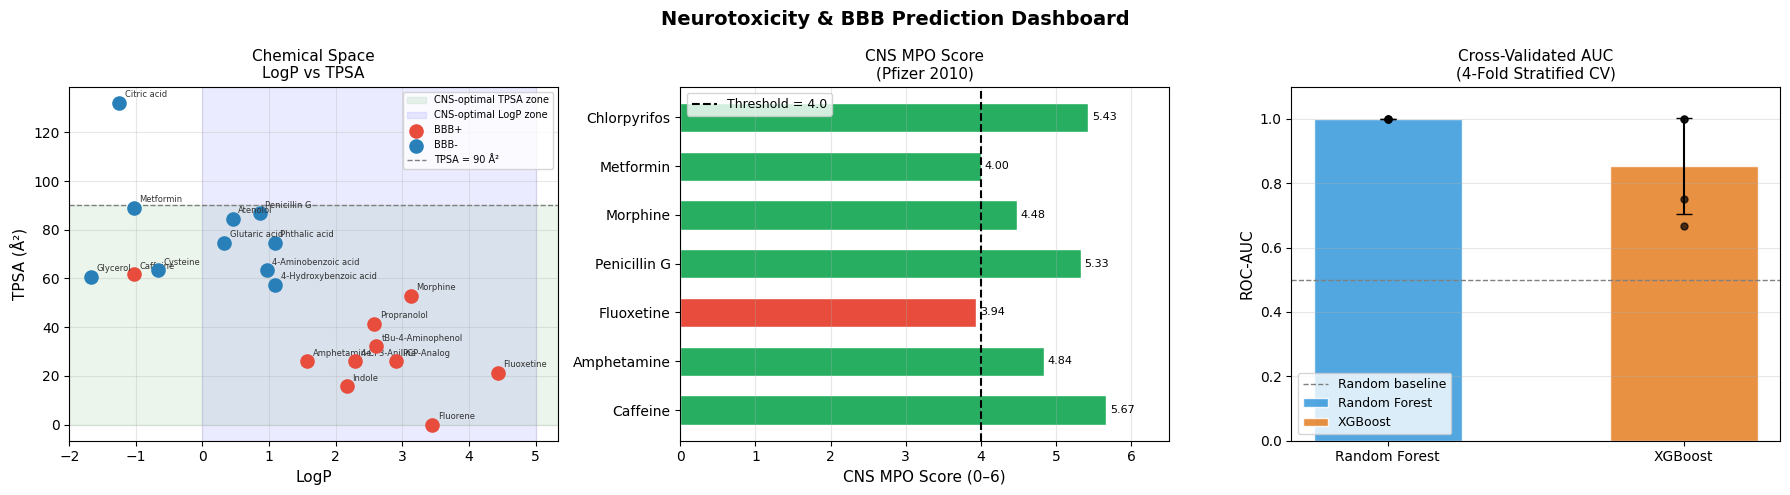

Figure saved → 04_neurotox_bbb_dashboard.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Neurotoxicity & BBB Prediction Dashboard", fontsize=14, fontweight="bold")

# ── Plot 1: Chemical space (LogP vs TPSA) ──────────────────────────────────
ax = axes[0]
ax.axhspan(0, 90,  alpha=0.08, color="green",  label="CNS-optimal TPSA zone")
ax.axvspan(0,  5,  alpha=0.08, color="blue",   label="CNS-optimal LogP zone")

colours = {1: "#e74c3c", 0: "#2980b9"}
labels_plotted = set()
for smi, lbl, name in bbb_data:
    mol  = Chem.MolFromSmiles(smi)
    logp = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)
    lbl_str = "BBB+" if lbl == 1 else "BBB-"
    kw = dict(c=colours[lbl], s=90, zorder=3,
              label=lbl_str if lbl_str not in labels_plotted else "")
    ax.scatter(logp, tpsa, **kw)
    ax.annotate(name, (logp, tpsa), textcoords="offset points",
                xytext=(4, 4), fontsize=6, color="#333333")
    labels_plotted.add(lbl_str)

ax.axhline(90, color="gray", lw=1, ls="--", label="TPSA = 90 Å²")
ax.set_xlabel("LogP", fontsize=11)
ax.set_ylabel("TPSA (Å²)", fontsize=11)
ax.set_title("Chemical Space\nLogP vs TPSA", fontsize=11)
ax.legend(fontsize=7, loc="upper right")
ax.grid(True, alpha=0.3)

# ── Plot 2: CNS MPO bar chart ───────────────────────────────────────────────
ax = axes[1]
bar_colors = ["#27ae60" if v >= 4 else "#e74c3c" for v in df_mpo["CNS_MPO"]]
bars = ax.barh(df_mpo["Compound"], df_mpo["CNS_MPO"], color=bar_colors, edgecolor="white", height=0.6)
ax.axvline(4.0, color="black", lw=1.5, ls="--", label="Threshold = 4.0")
ax.set_xlabel("CNS MPO Score (0–6)", fontsize=11)
ax.set_title("CNS MPO Score\n(Pfizer 2010)", fontsize=11)
ax.set_xlim(0, 6.5)
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)
for bar, val in zip(bars, df_mpo["CNS_MPO"]):
    ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=8)

# ── Plot 3: AUC fold comparison ─────────────────────────────────────────────
ax = axes[2]
model_names = list(cv_results.keys())
x = np.arange(len(model_names))
width = 0.35

for i, (mname, scores) in enumerate(cv_results.items()):
    aucs = scores["test_roc_auc"]
    ax.bar(i, aucs.mean(), width=0.5,
           color=["#3498db", "#e67e22"][i],
           yerr=aucs.std(), capsize=6,
           label=mname, alpha=0.85, edgecolor="white")
    ax.scatter([i] * len(aucs), aucs, color="black", s=25, zorder=5, alpha=0.7)

ax.axhline(0.5, color="gray", lw=1, ls="--", label="Random baseline")
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel("ROC-AUC", fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title("Cross-Validated AUC\n(4-Fold Stratified CV)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("04_neurotox_bbb_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → 04_neurotox_bbb_dashboard.png")

---
## Key Takeaways

### CNS Penetration Rules (in priority order)

| Rule | Threshold | Rationale |
|---|---|---|
| TPSA | < 90 Å² | Polar surface area limits passive diffusion |
| HBD | ≤ 3 | Donors desolvate slowly at lipid bilayer |
| MW | < 450 Da | Size exclusion by tight junctions |
| LogP | 0 – 5 | Must balance solubility and membrane partitioning |
| CNS MPO | ≥ 4.0 | Pfizer composite — best single-number filter |

### Neurotoxicity Assessment Pipeline
```
SMILES
  │
  ├─ BBB-Score / CNS MPO  ──► Can it enter the CNS?
  │
  ├─ AChE inhibition model ──► Does it disrupt cholinergic signalling?
  │
  └─ MEA functional assay  ──► Does it alter neuronal network activity?
                                (→ Tutorial 10)
```

### Industry Tools
- **pkCSM** — free online ADMET predictor (BBB, CYP, hERG)
- **SwissADME** — SIB ADME/druglikeness calculator
- **ADMETlab 3.0** — comprehensive ADMET + toxicity endpoint coverage
- **Schrodinger QikProp** — commercial, used in pharma workflows

### Regulatory Context
- **ICH S7A** — Safety pharmacology CNS battery (obligatory for NDA filing)
- **OECD 424** — Neurotoxicity study in rodents (repeated-dose)
- **EPA OPPTS 870.6200** — Neurotoxicity screening battery